In [1]:
!pip install ale_py stable_baselines3
!pip install --upgrade moviepy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.2/187.2 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 76.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import ale_py
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3.common.env_util import make_atari_env
from moviepy import ImageSequenceClip
import os

In [3]:
env_id = "ALE/Riverraid-v5"
env = make_atari_env(env_id,n_envs=1,seed=0)

array([[[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [110, 156,  66],
        [110, 156,  66],
        [110, 156,  66]],

       ...,

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]]], dtype=uint8)
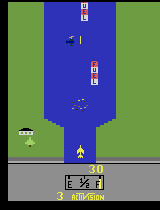

In [4]:
obs = env.reset()
env.render()

In [6]:
from stable_baselines3 import PPO,A2C
from stable_baselines3.common.evaluation import evaluate_policy
main_dir = "/content/drive/MyDrive/husob/06 ReinForcement Learning/008 Atari"
id=env_id.split("/")[-1]
total_steps = 1000_000


In [ ]:
model_PPO=PPO.load(f"{main_dir}/PPO_{id}_{total_steps}")
model_A2C=A2C(f"{main_dir}/A2C_{id}_{total_steps}")

In [ ]:
episodes=32
frames = []
reward_history_after_PPO = []
episodes_total_reward = 0

for episode  in range(episodes):
    obs = env.reset()
    done = False
    total_reward = 0
    while not done:
        action = model_PPO.predict(obs)[0]
        action = [action]
        obs,reward,done,info = env.step(action)
        total_reward += reward[0]
        frames.append(env.render())
    episodes_total_reward += total_reward
    reward_history_after_PPO.append(total_reward)
    print(f"aftere Training - Episode {episode+1} - Total Reward: {total_reward}")

print(f"Average Reward after Training: {np.mean(reward_history_after_PPO)}")

main_dir = "/content/drive/MyDrive/husob/06 ReinForcement Learning/008 Atari"
id=env_id.split("/")[-1]
clip_id = f"POP-{id}.mp4"
clip_path  = os.path.join(main_dir,clip_id)

print("Creating Video , please wait ...")

clip = ImageSequenceClip(frames,fps=10)
clip.write_videofile(clip_path)
print("Video Created Successfully")
# env.close()

In [ ]:
episodes=32
frames = []
reward_history_after_PPO = []
episodes_total_reward = 0

for episode  in range(episodes):
    obs = env.reset()
    done = False
    total_reward = 0
    while not done:
        action = model_A2C.predict(obs)[0]
        action = [action]
        obs,reward,done,info = env.step(action)
        total_reward += reward[0]
        frames.append(env.render())
    episodes_total_reward += total_reward
    reward_history_after_PPO.append(total_reward)
    print(f"aftere Training - Episode {episode+1} - Total Reward: {total_reward}")

print(f"Average Reward after Training: {np.mean(reward_history_after_PPO)}")

main_dir = "/content/drive/MyDrive/husob/06 ReinForcement Learning/008 Atari"
id=env_id.split("/")[-1]
clip_id = f"A2C-{id}.mp4"
clip_path  = os.path.join(main_dir,clip_id)

print("Creating Video , please wait ...")

clip = ImageSequenceClip(frames,fps=10)
clip.write_videofile(clip_path)
print("Video Created Successfully")

env.close()